In [10]:
import numpy as np

data = np.load("Lx_12_MPI_results.npz")
print(data.files)  # 保存されているキーの一覧を表示
data.close()

['pg', 'TEE_ave', 'TEE_err', 'TEE_var']


In [9]:
import numpy as np

data = np.load("Lx_12_MPI_results.npz")
print(data['pg'])
print(data['TEE_ave'])
print(data['TEE_err'])
print(data['TEE_var'])
data.close()

[0.5  0.55 0.6  0.65 0.7  0.75 0.8  0.85 0.9  0.95 1.  ]
[ 0.01  0.04  0.04 -0.02 -0.13 -0.3  -0.43 -0.59 -0.72 -0.83 -0.91]
[0.02245084 0.01969464 0.02814106 0.02       0.04181489 0.05595814
 0.05174725 0.04943111 0.04512609 0.03775252 0.02876235]
[0.0499 0.0384 0.0784 0.0396 0.1731 0.31   0.2651 0.2419 0.2016 0.1411
 0.0819]


ValueError: invalid literal for int() with base 10: '0.0'

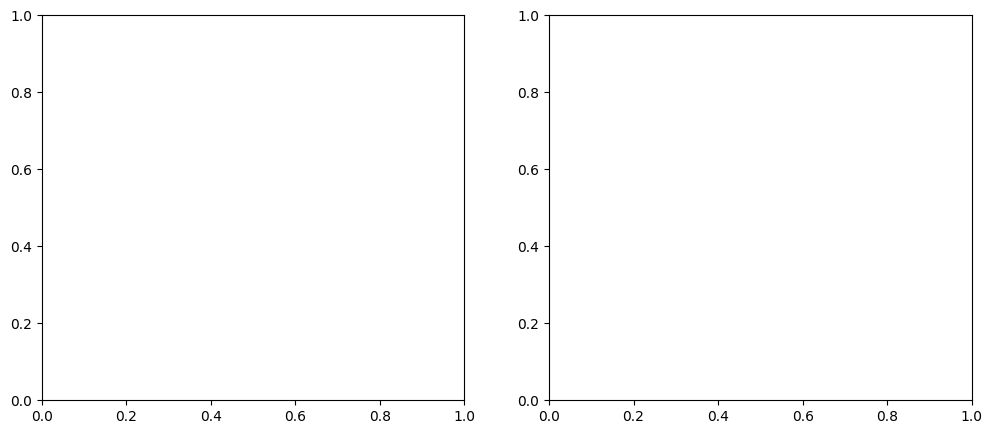

In [58]:
import numpy as np
import matplotlib.pyplot as plt
import glob


cmap = plt.colormaps['gnuplot']
# npzファイルのパターン。Lxの値が変わる場合にマッチさせる
#files = glob.glob("Lx_*_MPI_results.npz")
files = glob.glob("px_0.0_Lx_*_MPI_results.npz")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

for file in files:
    data = np.load(file)
    # ファイル名からLxの値を抽出 (例: Lx_12_MPI_results.npz → 12)
    Lx_str = file.split("_")[1]  # '12'の部分
    Lx = int(Lx_str)
    #Lx_str = file.split("_")[1]  # '12'の部分
    #Lx = Lx_str

    pg = data['pg']
    TEE_ave = data['TEE_ave']
    TEE_err = data['TEE_err']
    TEE_var = data['TEE_var']

    data.close()

    label = f"Lx={Lx}"
    # 左グラフ：TEEの平均値＋誤差バー
    ax[0].errorbar(pg, TEE_ave, yerr=TEE_err,fmt='o-', capsize=5, label=label)
    # 右グラフ：TEEの分散
    ax[1].plot(pg, TEE_var, 's--', label=label)
    print(px)

ax[0].set_xlabel('p_g')
ax[0].set_ylabel('TEE')
ax[0].set_title('TEE vs p_g')
ax[0].grid(True)
ax[0].legend()

ax[1].set_xlabel('p_g')
ax[1].set_ylabel('Variance of TEE')
ax[1].set_title('Variance vs p_g')
ax[1].grid(True)
ax[1].legend()

plt.tight_layout()
plt.show()


In [48]:
Np=11
ps=0.5
for ip in range (Np):
    px=0.1
    pg=ps+(1-px-ps)*ip/(Np-1)
    print(pg)

0.5
0.54
0.58
0.62
0.66
0.7
0.74
0.78
0.8200000000000001
0.86
0.9
